# 02 - Fourier Strategy: Filtrado, Señales y Backtest

Este notebook aplica el filtrado por Fourier para generar señales de trading (crossover precio vs señal filtrada) y ejecuta un backtest con `backtesting`.

## 1. Setup e importaciones

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

from backtesting import Strategy

from curso.lib.data import download_historical, download_multiple, interpolate_gaps
from curso.lib.backtest import run_backtest

plt.style.use('seaborn-v0_8-whitegrid')
print('Imports cargados ✓')

/Users/rolmov/Documents/github/sdd-project/.venv/lib/python3.12/site-packages/backtesting/_plotting.py:50: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support (e.g. PyCharm, Spyder IDE). Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

Imports cargados ✓


## 2. Parámetros y helpers FFT

In [2]:
# Parámetros
TICKER = 'AAPL'
LOOKBACK_YEARS = 5
FFT_TOP_N = 2
MIN_PERIOD = 10
MAX_PERIOD = 80
PAD_TO_POWER_OF_2 = True

# Helpers

def compute_fft_cycles(series, top_n=2, min_period=10, max_period=80, pad=True):
    """Devuelve (fft_coeffs, freqs, power, top_idx) para una serie de precios."""
    vals = series.values
    N = len(vals)
    if pad:
        next_pow2 = 1 << (N - 1).bit_length()
        pad_n = next_pow2 if next_pow2 >= N else N
    else:
        pad_n = N
    if pad_n > N:
        vals_p = np.concatenate([vals, np.zeros(pad_n - N)])
    else:
        vals_p = vals.copy()
    fft_coeffs = np.fft.rfft(vals_p)
    power = (np.abs(fft_coeffs) ** 2) / len(vals_p)
    freqs = np.fft.rfftfreq(len(vals_p), d=1.0)
    periods = np.full_like(freqs, np.nan, dtype=float)
    nz = freqs > 0
    periods[nz] = 1.0 / freqs[nz]
    valid_idx = np.where((periods >= min_period) & (periods <= max_period))[0]
    if len(valid_idx) == 0:
        return fft_coeffs, freqs, power, np.array([], dtype=int)
    sorted_idx = valid_idx[np.argsort(power[valid_idx])[::-1]]
    top_idx = sorted_idx[:top_n]
    return fft_coeffs, freqs, power, top_idx


def apply_fourier_filter(fft_coeffs, keep_idx, n_out, pad_n=None):
    """Construye la señal filtrada conservando solo índices keep_idx en coeficientes FFT."""
    fft_filtered = np.zeros_like(fft_coeffs, dtype=complex)
    for i in keep_idx:
        fft_filtered[i] = fft_coeffs[i]
    # Inversa
    if pad_n is None:
        n = n_out
    else:
        n = pad_n
    filtered = np.fft.irfft(fft_filtered, n=n)
    return filtered[:n_out]

print('Helpers definidos')

Helpers definidos


## 3. Descargar datos y calcular señal filtrada

In [3]:
# Descargar datos
raw = download_historical(TICKER)
raw = raw.sort_index()
try:
    raw = interpolate_gaps(raw)
except Exception:
    raw = raw.interpolate(method='linear').ffill().bfill()

close = raw['Close'].astype(float).dropna()
N = len(close)

# Calcular FFT y top indices
fft_coeffs, freqs, power, top_idx = compute_fft_cycles(close, top_n=FFT_TOP_N, min_period=MIN_PERIOD, max_period=MAX_PERIOD, pad=PAD_TO_POWER_OF_2)

# Aplicar filtro (necesitamos pad_n usado dentro de helper; recomputar pad_n)
next_pow2 = 1 << (N - 1).bit_length()
pad_n = next_pow2 if next_pow2 >= N else N
filtered = apply_fourier_filter(fft_coeffs, top_idx, n_out=N, pad_n=pad_n)

# Añadir columna filtrada al DataFrame
data = raw.copy()
data['Filtered'] = filtered

print(f'Señal filtrada calculada con top_idx={list(top_idx)}')

Señal filtrada calculada con top_idx=[35, 40]


## 4. Generar señales de crossover (precio vs señal filtrada)

/var/folders/zw/_9_z_l6x04d1k88c2d84lwym0000gp/T/ipykernel_60103/1006781591.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['above_filtered_prev'] = data['above_filtered'].shift(1).fillna(False)


Entradas: 1, Salidas: 0


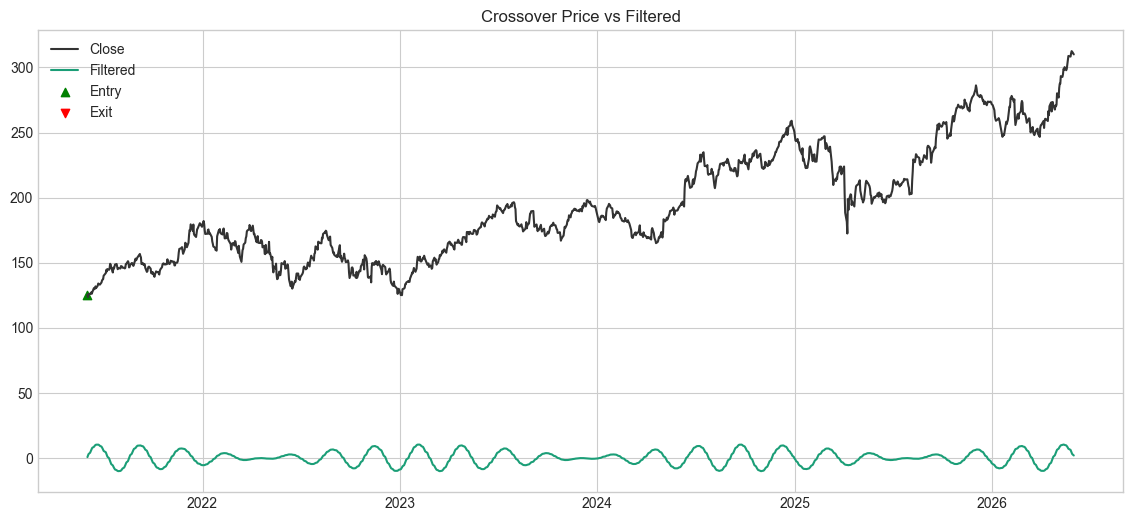

In [4]:
# Señales simples: buy cuando Close cruza por encima de Filtered, sell cuando cruza por debajo
data = data.dropna(subset=['Close', 'Filtered']).copy()

data['above_filtered'] = data['Close'] > data['Filtered']
data['above_filtered_prev'] = data['above_filtered'].shift(1).fillna(False)

data['entry_signal'] = (~data['above_filtered_prev']) & (data['above_filtered'])
data['exit_signal'] = (data['above_filtered_prev']) & (~data['above_filtered'])

# Mostrar número de señales
n_entries = data['entry_signal'].sum()
n_exits = data['exit_signal'].sum()
print(f'Entradas: {n_entries}, Salidas: {n_exits}')

# Plot ejemplo con marcadores
plt.figure(figsize=(14,6))
plt.plot(data.index, data['Close'], label='Close', color='#333')
plt.plot(data.index, data['Filtered'], label='Filtered', color='#1b9e77')
plt.scatter(data.index[data['entry_signal']], data['Close'][data['entry_signal']], marker='^', color='green', label='Entry')
plt.scatter(data.index[data['exit_signal']], data['Close'][data['exit_signal']], marker='v', color='red', label='Exit')
plt.legend(); plt.title('Crossover Price vs Filtered')
plt.show()

## 5. Backtest con `backtesting.py` usando la señal filtrada

In [5]:
class FourierStrategy(Strategy):
    """Strategy que ejecuta compras/ventas basadas en la señal filtrada en la columna 'Filtered'."""
    def init(self):
        # Nada para inicializar porque usamos columna precomputada
        pass

    def next(self):
        price = self.data.Close[-1]
        filtered = self.data.Filtered[-1]
        if not self.position:
            if price > filtered:
                self.buy()
        else:
            if price < filtered:
                # Cerrar posición
                self.position.close()

# Preparar DataFrame para backtesting: requiere columnas Open, High, Low, Close, Volume
bt_df = data[['Open','High','Low','Close','Volume','Filtered']].copy()

# Ejecutar backtest
stats, bt = run_backtest(bt_df, FourierStrategy, cash=10_000, commission=0.002)

print(stats)

# bt.plot()  # Opcional: genera gráfico interactivo con Bokeh

Start                     2021-06-02 00:00:00
End                       2026-06-01 00:00:00
Duration                   1825 days 00:00:00
Exposure Time [%]                   99.840637
Equity Final [$]                 24817.349117
Equity Peak [$]                  25055.349606
Return [%]                         148.173491
Buy & Hold Return [%]              147.893028
Return (Ann.) [%]                   20.023317
Volatility (Ann.) [%]               33.369336
Sharpe Ratio                         0.600051
Sortino Ratio                        1.090866
Calmar Ratio                         0.600473
Max. Drawdown [%]                  -33.345928
Avg. Drawdown [%]                   -4.412715
Max. Drawdown Duration      525 days 00:00:00
Avg. Drawdown Duration       41 days 00:00:00
# Trades                                    1
Win Rate [%]                            100.0
Best Trade [%]                     148.986193
Worst Trade [%]                    148.986193
Avg. Trade [%]                    

## 6. Comparación con Buy & Hold

In [6]:
# Calcular buy & hold desde primera fecha a última
initial_price = data['Close'].iloc[0]
final_price = data['Close'].iloc[-1]
bh_return = (final_price / initial_price - 1) * 100
print(f'Buy & Hold return: {bh_return:.2f}%')

# Mostrar métricas relevantes del backtest
print('Sharpe Ratio (backtest):', stats['Sharpe Ratio'] if 'Sharpe Ratio' in stats.index else stats.get('Sharpe Ratio', 'N/A'))
print('Max Drawdown:', stats['Max. Drawdown'] if 'Max. Drawdown' in stats.index else stats.get('Max. Drawdown', 'N/A'))

Buy & Hold return: 147.89%
Sharpe Ratio (backtest): 0.6000514068330646
Max Drawdown: N/A


## 7. (Opcional) Comparación multi-activo — ranking por estabilidad cíclica

In [7]:
TICKERS = ['AAPL','MSFT','GOOGL','AMZN','META']
multi = download_multiple(TICKERS)

rows = []
for t, df_t in multi.items():
    df_t = df_t.sort_index()
    try:
        df_t = interpolate_gaps(df_t)
    except Exception:
        df_t = df_t.interpolate().ffill().bfill()
    close_t = df_t['Close'].astype(float).dropna()
    fft_c, freqs_c, power_c, top_idx_c = compute_fft_cycles(close_t, top_n=3, min_period=MIN_PERIOD, max_period=MAX_PERIOD, pad=PAD_TO_POWER_OF_2)
    top_powers = power_c[top_idx_c] if len(top_idx_c)>0 else np.array([0])
    stability = np.std(top_powers)/np.mean(top_powers) if len(top_powers)>1 and np.mean(top_powers)!=0 else 0
    period_vals = (1.0 / freqs_c[top_idx_c]) if len(top_idx_c)>0 else np.array([np.nan])
    rows.append({'ticker': t, 'dominant_periods': ','.join([str(int(p)) for p in period_vals]), 'stability': float(np.round(stability,6))})

rank_df = pd.DataFrame(rows).sort_values('stability')
rank_df

,ticker,dominant_periods,stability
0,AAPL,"58,51,68",0.046290
2,GOOGL,"75,64,58",0.135910
3,AMZN,"75,68,64",0.175648
1,MSFT,"75,68,51",0.176188
4,META,"75,78,51",0.434358


## 8. Conclusiones y siguientes pasos

- Ajustar `FFT_TOP_N`, `MIN_PERIOD`, `MAX_PERIOD` para adaptar la estrategia al horizonte deseado.
- Considerar ventanas móviles y recalcular FFT periódicamente para adaptarse a cambios de régimen.
- Probar combinaciones con otros filtros (SMA, RSI) para robustecer señales.